In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv(r"C:\Users\Riya Joshi\Downloads\all_data (3).csv")


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ifInOctets11         4998 non-null   int64 
 1   ifOutOctets11        4998 non-null   int64 
 2   ifoutDiscards11      4998 non-null   int64 
 3   ifInUcastPkts11      4998 non-null   int64 
 4   ifInNUcastPkts11     4998 non-null   int64 
 5   ifInDiscards11       4998 non-null   int64 
 6   ifOutUcastPkts11     4998 non-null   int64 
 7   ifOutNUcastPkts11    4998 non-null   int64 
 8   tcpOutRsts           4998 non-null   int64 
 9   tcpInSegs            4998 non-null   int64 
 10  tcpOutSegs           4998 non-null   int64 
 11  tcpPassiveOpens      4998 non-null   int64 
 12  tcpRetransSegs       4998 non-null   int64 
 13  tcpCurrEstab         4998 non-null   int64 
 14  tcpEstabResets       4998 non-null   int64 
 15  tcp?ActiveOpens      4998 non-null   int64 
 16  udpInD

In [5]:
data.isnull().sum()

ifInOctets11           0
ifOutOctets11          0
ifoutDiscards11        0
ifInUcastPkts11        0
ifInNUcastPkts11       0
ifInDiscards11         0
ifOutUcastPkts11       0
ifOutNUcastPkts11      0
tcpOutRsts             0
tcpInSegs              0
tcpOutSegs             0
tcpPassiveOpens        0
tcpRetransSegs         0
tcpCurrEstab           0
tcpEstabResets         0
tcp?ActiveOpens        0
udpInDatagrams         0
udpOutDatagrams        0
udpInErrors            0
udpNoPorts             0
ipInReceives           0
ipInDelivers           0
ipOutRequests          0
ipOutDiscards          0
ipInDiscards           0
ipForwDatagrams        0
ipOutNoRoutes          0
ipInAddrErrors         0
icmpInMsgs             0
icmpInDestUnreachs     0
icmpOutMsgs            0
icmpOutDestUnreachs    0
icmpInEchos            0
icmpOutEchoReps        0
class                  0
dtype: int64

In [6]:
data['class'].value_counts()


tcp-syn       960
slowloris     780
udp-flood     773
icmp-echo     632
normal        600
httpFlood     573
slowpost      480
bruteForce    200
Name: class, dtype: int64

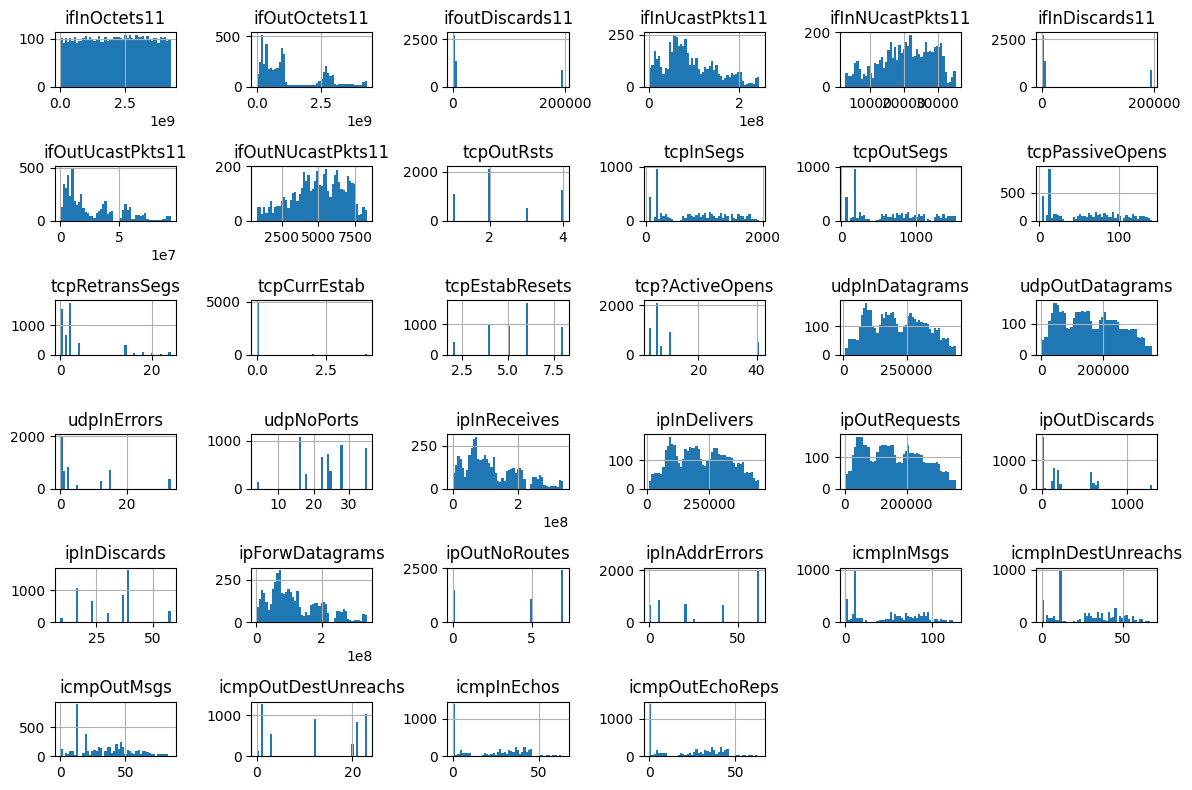

In [7]:
import matplotlib.pyplot as plt
data.hist(bins=50 , figsize=(12,8))
plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
data[['class']] = encoder.fit_transform(data[['class']])

In [9]:
data.columns

Index(['ifInOctets11', 'ifOutOctets11', 'ifoutDiscards11', 'ifInUcastPkts11',
       'ifInNUcastPkts11', 'ifInDiscards11', 'ifOutUcastPkts11',
       'ifOutNUcastPkts11', 'tcpOutRsts', 'tcpInSegs', 'tcpOutSegs',
       'tcpPassiveOpens', 'tcpRetransSegs', 'tcpCurrEstab', 'tcpEstabResets',
       'tcp?ActiveOpens', 'udpInDatagrams', 'udpOutDatagrams', 'udpInErrors',
       'udpNoPorts', 'ipInReceives', 'ipInDelivers', 'ipOutRequests',
       'ipOutDiscards', 'ipInDiscards', 'ipForwDatagrams', 'ipOutNoRoutes',
       'ipInAddrErrors', 'icmpInMsgs', 'icmpInDestUnreachs', 'icmpOutMsgs',
       'icmpOutDestUnreachs', 'icmpInEchos', 'icmpOutEchoReps', 'class'],
      dtype='object')

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X = pca.fit_transform(data_scaled)

In [12]:
pca.n_components_


9

In [13]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5 , min_samples=3)
dbscan.fit(X)

DBSCAN(min_samples=3)

In [14]:
dbscan.labels_

array([ 0,  0,  0, ..., 50, 50, 50], dtype=int64)

In [15]:
labels = dbscan.labels_


In [16]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points (anomalies): {n_noise}")

Estimated number of clusters: 51
Estimated number of noise points (anomalies): 65


In [17]:
data_new=pd.concat([data, pd.DataFrame({'type':labels})], axis=1)
data_new.head()

,ifInOctets11,ifOutOctets11,ifoutDiscards11,ifInUcastPkts11,ifInNUcastPkts11,ifInDiscards11,ifOutUcastPkts11,ifOutNUcastPkts11,tcpOutRsts,tcpInSegs,...,ipOutNoRoutes,ipInAddrErrors,icmpInMsgs,icmpInDestUnreachs,icmpOutMsgs,icmpOutDestUnreachs,icmpInEchos,icmpOutEchoReps,class,type
0,1867925250,902237363,0,52007310,16978,0,7197292,3968,1,682,...,7,0,49,26,46,23,23,23,3.0,0
1,1994338334,903845459,0,52098054,16986,0,7227073,3968,1,682,...,7,0,49,26,46,23,23,23,3.0,0
2,2116573334,905396546,0,52185853,16994,0,7255792,3969,1,682,...,7,0,49,26,46,23,23,23,3.0,0
3,2257767832,907308930,0,52287097,17015,0,7291152,3975,1,701,...,7,0,51,27,47,23,24,24,3.0,-1
4,2342047724,908534112,0,52347521,17043,0,7313830,3977,1,709,...,7,0,51,27,47,23,24,24,3.0,0


In [18]:
convert = lambda x : "anomalous" if(x == -1) else "normal"

In [19]:
data_new['type'] = data_new['type'].apply(convert)


In [20]:
data_new.head()


,ifInOctets11,ifOutOctets11,ifoutDiscards11,ifInUcastPkts11,ifInNUcastPkts11,ifInDiscards11,ifOutUcastPkts11,ifOutNUcastPkts11,tcpOutRsts,tcpInSegs,...,ipOutNoRoutes,ipInAddrErrors,icmpInMsgs,icmpInDestUnreachs,icmpOutMsgs,icmpOutDestUnreachs,icmpInEchos,icmpOutEchoReps,class,type
0,1867925250,902237363,0,52007310,16978,0,7197292,3968,1,682,...,7,0,49,26,46,23,23,23,3.0,normal
1,1994338334,903845459,0,52098054,16986,0,7227073,3968,1,682,...,7,0,49,26,46,23,23,23,3.0,normal
2,2116573334,905396546,0,52185853,16994,0,7255792,3969,1,682,...,7,0,49,26,46,23,23,23,3.0,normal
3,2257767832,907308930,0,52287097,17015,0,7291152,3975,1,701,...,7,0,51,27,47,23,24,24,3.0,anomalous
4,2342047724,908534112,0,52347521,17043,0,7313830,3977,1,709,...,7,0,51,27,47,23,24,24,3.0,normal


<AxesSubplot:xlabel='type', ylabel='count'>

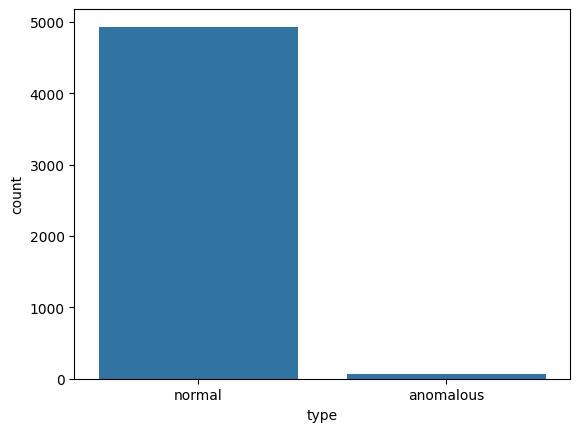

In [21]:
import seaborn as sn
sn.countplot(x='type' , data=data_new)

<AxesSubplot:xlabel='class', ylabel='count'>

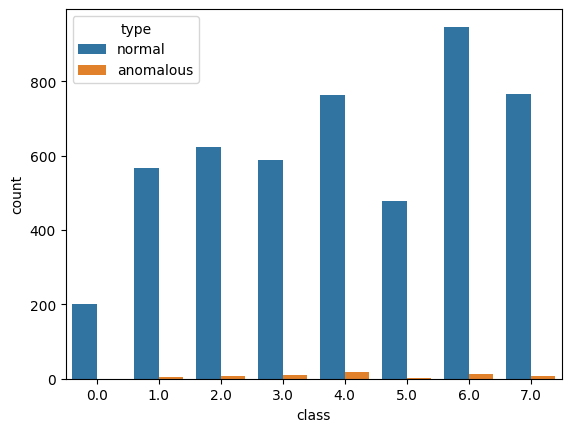

In [22]:
sn.countplot(x ='class',hue='type',data = data_new)

In [23]:
y = encoder.fit_transform(data_new[['type']])

Text(0, 0.5, 'Eigth Factor')

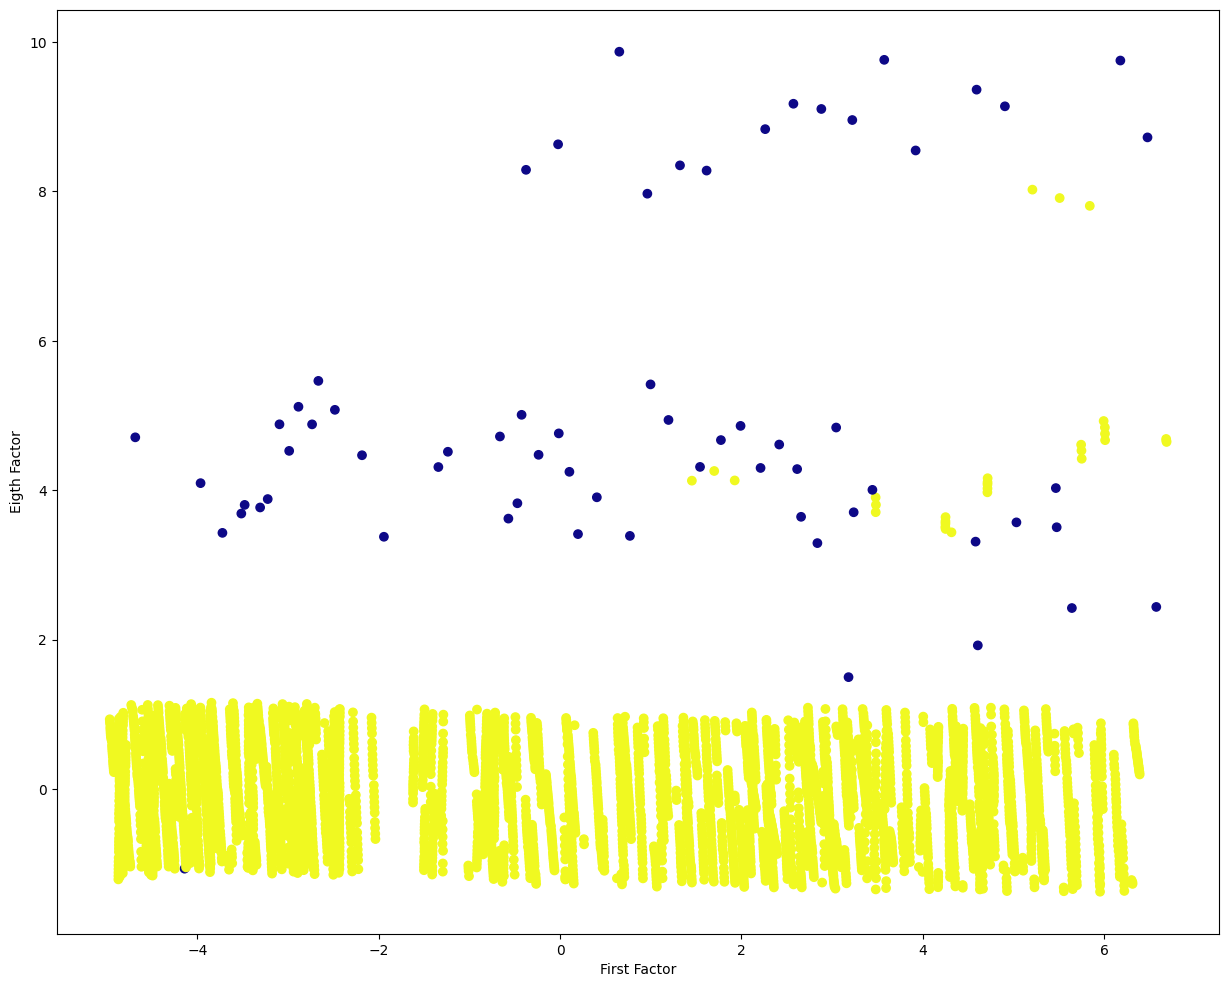

In [24]:
plt.figure(figsize=(15,12))
plt.scatter(X[:,0],X[:,7],c=y,cmap='plasma')
plt.xlabel('First Factor')
plt.ylabel('Eigth Factor')

In [25]:
X = data_new.drop(['type'],axis=1)


In [26]:
from sklearn.model_selection import train_test_split
X_train ,X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)


In [27]:
X_train.shape

(3998, 35)

In [28]:
y_train.shape

(3998, 1)

In [29]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier

In [30]:
clf = LocalOutlierFactor(n_neighbors=3, contamination=0.013, novelty=True)
clf.fit(X_train , y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test , y_pred)*100
print(f"Accuracy of the model : {acc} %")

Accuracy of the model : 97.2 %


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load a sample dataset (You can replace this with your own dataset)
data = load_iris()
X = data.data
y = data.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Print the classification report (do not specify 'average' for multiclass)
print("\nRandom Forest Performance:")
print(classification_report(y_test, y_pred_rf))

# Calculate F1 score (weighted average for multiclass)
f1 = f1_score(y_test, y_pred_rf, average='weighted')
print(f"F1 Score: {f1:.4f}")

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))



Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

F1 Score: 1.0000
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [32]:
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train , y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test , y_pred)*100
print(f"Accuracy of the model : {acc} %")

Accuracy of the model : 100.0 %


In [33]:
from sklearn.metrics import classification_report, confusion_matrix

# After prediction
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


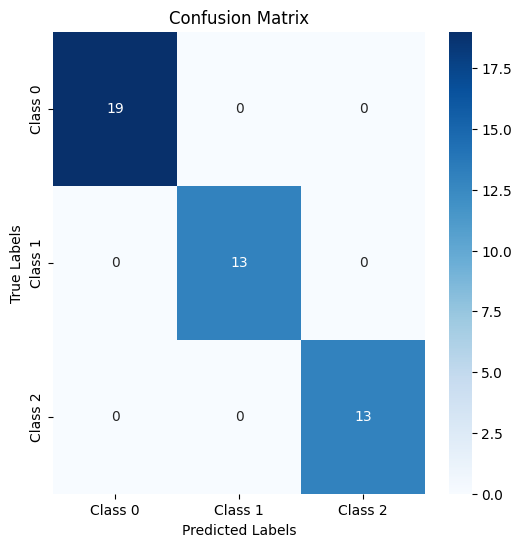

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1", "Class 2"], yticklabels=["Class 0", "Class 1", "Class 2"])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [38]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation and get the average accuracy score
scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-validation scores: {scores}')
print(f'Mean cross-validation score: {scores.mean()}')



Cross-validation scores: [0.9047619  0.9047619  0.9047619  1.         0.95238095]
Mean cross-validation score: 0.9333333333333333


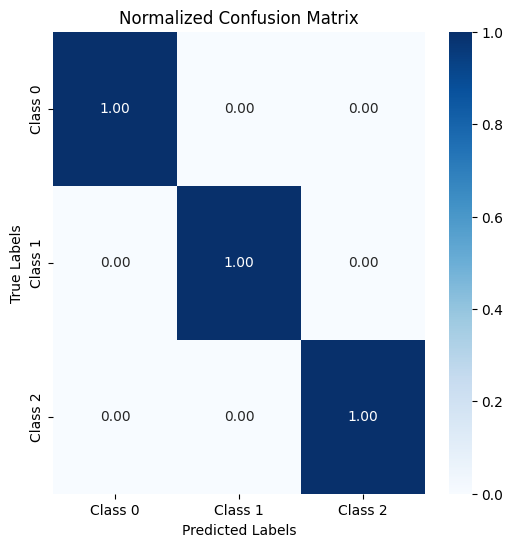

In [39]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6, 6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=["Class 0", "Class 1", "Class 2"], yticklabels=["Class 0", "Class 1", "Class 2"])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix')
plt.show()
